<a href="https://colab.research.google.com/github/Ishany0/PM2.5_AirQuality/blob/main/Using_inbuilt_mlpRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
PSRA_data = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')
df = pd.DataFrame(PSRA_data)

df = df.dropna()
encoded_df = pd.get_dummies(df , columns = ['cbwd'] , drop_first = True)

In [4]:
feature_cols = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'month', 'hour'] + \
               [c for c in encoded_df.columns if c.startswith('cbwd_')]

X = encoded_df[feature_cols].values.astype(float)
Y = encoded_df['pm2.5'].values.reshape(-1, 1).astype(float)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [10]:
mlp.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [11]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(Y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))

print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

Train R²: 0.5749  |  Test R²: 0.5360
Train RMSE: 59.7150  |  Test RMSE: 63.9444


Train R²: 0.5749  |  Test R²: 0.5360
Train RMSE: 59.7150  |  Test RMSE: 63.9444


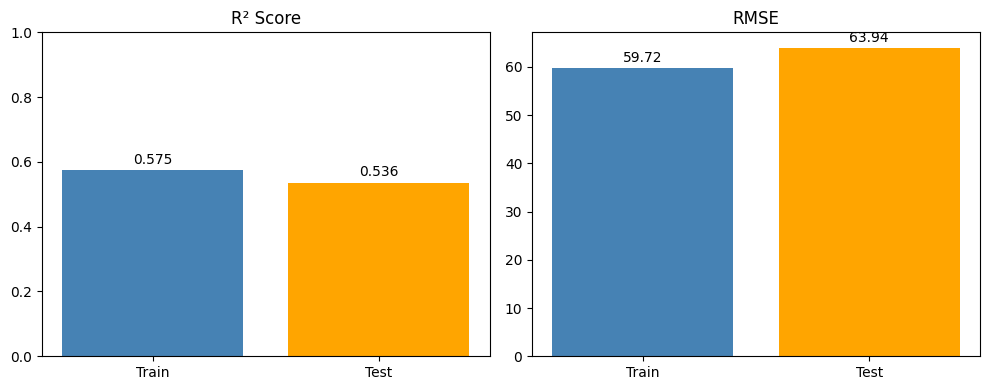

In [12]:
from sklearn.metrics import r2_score, root_mean_squared_error


train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = root_mean_squared_error(Y_train, y_train_pred)
test_rmse = root_mean_squared_error(Y_test, y_test_pred)
print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [train_r2, test_r2], color=['steelblue', 'orange'])
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate([train_r2, test_r2]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center')

axes[1].bar(['Train', 'Test'], [train_rmse, test_rmse], color=['steelblue', 'orange'])
axes[1].set_title('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v + max(train_rmse, test_rmse) * 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()